In [1]:
import requests
import os
import pandas as pd
from database import check

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [17]:
item_id = "CaveTrollsPreciousRock"
condense,has_sold = True,True
interval = '3m' # 3m is smallest accepted interval
start,end = '2025-10-07','2025-10-14' # 2025-10-07 was start of season 7 semi semi wipe
limit,page = '50','1'

def url():
    url = (
        f'https://api.darkerdb.com/v1/market/analytics/{item_id}/prices/history'
        f'?key={os.getenv("dark_api_key")}'
        f'&interval={interval}'
        f'&from={start}&to={end}'
    )
    return url
req = requests.get(url())

In [18]:
with requests.Session() as ses:
    bodyList = []
    get = 1
    req = ses.get(url())

    while req.json()['body'] != []:
        bodyList.extend(req.json()['body'])
        end = req.json()['body'][0]['timestamp']
        req = ses.get(url())

        print(f'get {get}', end="\r")
        get += 1
df = pd.json_normalize(bodyList, sep=',')
# df

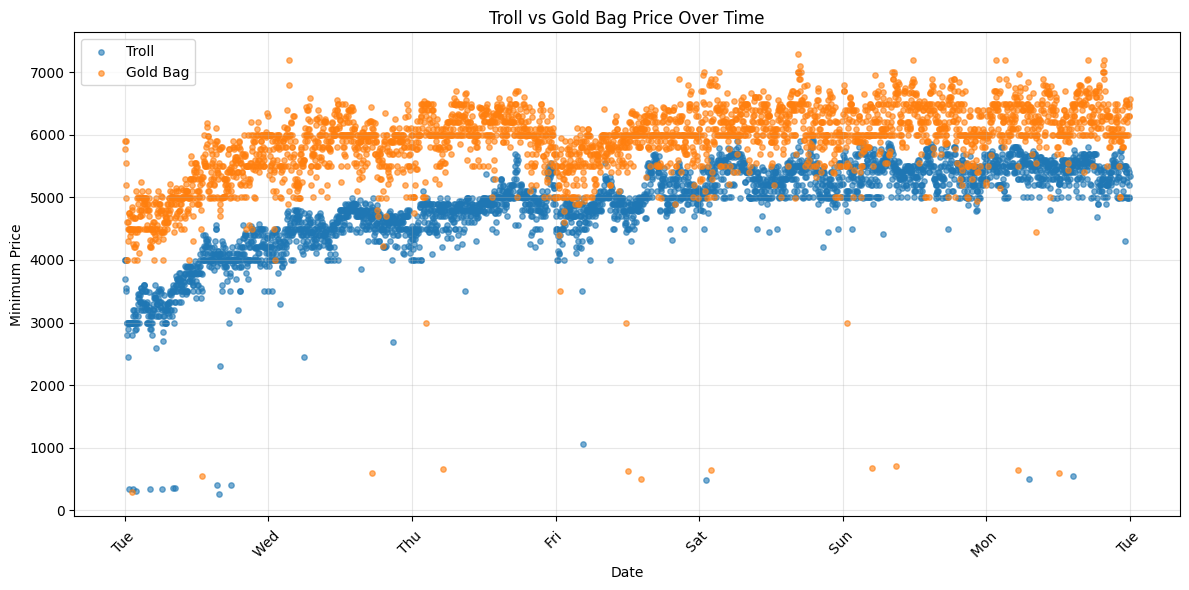

In [12]:
# ensure timestamps are datetimes for hourly locators
troll_df['timestamp'] = pd.to_datetime(troll_df['timestamp'])
goldbag_df['timestamp'] = pd.to_datetime(goldbag_df['timestamp'])

fig, ax = plt.subplots(figsize=(12, 6))
ax.scatter(troll_df['timestamp'], troll_df['min'], label='Troll', s=15, alpha=0.6)
ax.scatter(goldbag_df['timestamp'], goldbag_df['min'], label='Gold Bag', s=15, alpha=0.6)

ax.set_title("Troll vs Gold Bag Price Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Minimum Price")
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%a '))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()